# Extended Kalman Filter: Pendulum State Estimation

## Learning Objectives

- Implement an Extended Kalman Filter (EKF) from scratch using NumPy
- Simulate a pendulum in MuJoCo and use it as ground truth
- Verify analytical Jacobians against numerical finite differences
- Estimate velocity from position-only measurements
- Develop intuition for process noise (Q) and measurement noise (R) tuning
- Visualize EKF tracking performance with estimated vs. true trajectories

## What is State Estimation?

Imagine you have a pendulum swinging, but you can only measure its angle -- not how fast it is moving. State estimation is the art of combining a noisy measurement with a mathematical model of the system to figure out the *full* state (both angle and velocity). The Extended Kalman Filter does this by repeatedly predicting what should happen next and then correcting that prediction when a new measurement arrives.

## Section 2: Setup

We begin by importing the libraries we need and loading the MuJoCo pendulum model.

In [1]:
import dms
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import mediapy as media
from scipy.optimize import approx_fprime
import ipywidgets
from ipywidgets import interact_manual, FloatLogSlider

# Load the pendulum model
model_path = dms.get_asset_path("mujoco_models/pendulum.xml")
model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

print(f"Model loaded: {model.nq} position DOF, {model.nv} velocity DOF")
print(f"Timestep: {model.opt.timestep} s")
print(f"Gravity: {model.opt.gravity}")

ModuleNotFoundError: No module named 'dms'

## Section 3: Pendulum Simulation

The pendulum has two state variables:
- **theta** -- the angle of the pendulum from vertical
- **omega** -- the angular velocity (how fast the angle is changing)

Together, these form the state vector: $\mathbf{x} = \begin{bmatrix} \theta \\ \omega \end{bmatrix}$

Let's simulate the pendulum for 5 seconds and collect ground truth states. We give it an initial angle of 0.5 radians (about 29 degrees) so it has something to swing about.

In [2]:
# Simulation parameters
duration = 5.0     # seconds
framerate = 30     # Hz for video capture
dt = model.opt.timestep  # MuJoCo timestep (0.002 s)

# Reset simulation and set initial conditions
mujoco.mj_resetData(model, data)
data.qpos[0] = 0.5  # Initial angle: 0.5 rad (~29 degrees)
data.qvel[0] = 0.0  # Start from rest
mujoco.mj_forward(model, data)  # Compute initial derived quantities

# Storage for ground truth and video frames
true_states = []   # List of (2,1) column vectors
times = []         # Time values
frames = []        # Video frames

# Run simulation
while data.time < duration:
    # Store ground truth BEFORE stepping (use .copy() to avoid MuJoCo buffer mutation)
    true_theta = data.qpos[0].copy()
    true_omega = data.qvel[0].copy()
    true_states.append(np.array([[true_theta], [true_omega]]))
    times.append(data.time)

    # Capture video frame at the desired framerate
    if len(frames) < data.time * framerate:
        renderer.update_scene(data, camera="side")
        frames.append(renderer.render().copy())

    # Step physics
    mujoco.mj_step(model, data)

times = np.array(times)
print(f"Simulation complete: {len(true_states)} timesteps, {len(frames)} video frames")
print(f"Time range: {times[0]:.3f} to {times[-1]:.3f} s")
print(f"State shape: {true_states[0].shape} (column vector)")

Simulation complete: 2501 timesteps, 150 video frames
Time range: 0.000 to 5.000 s
State shape: (2, 1) (column vector)


In [3]:
# Display pendulum video
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


## Section 4a: Full State Measurements (Baseline)

Before tackling the harder problem, let's establish a baseline. Imagine we have **ideal sensors** that measure *both* angle and velocity, but with some noise. This is the easiest case for state estimation -- we observe everything directly.

We'll use this baseline to compare against position-only estimation later.

In [4]:
# Full state measurements: observe BOTH theta and omega with noise
noise_std_full = 0.05   # Same noise level for position
vel_noise_std = 0.5     # Velocity sensor is noisier (typical for real systems)

np.random.seed(42)
full_measurements = []
for state in true_states:
    true_theta = state[0, 0]
    true_omega = state[1, 0]
    noisy_theta = true_theta + np.random.randn() * noise_std_full
    noisy_omega = true_omega + np.random.randn() * vel_noise_std
    full_measurements.append(np.array([[noisy_theta], [noisy_omega]]))  # (2,1) column vector

print(f"Full-state measurements: {len(full_measurements)} timesteps")
print(f"Measurement shape: {full_measurements[0].shape} (both theta and omega)")
print(f"Position noise: {noise_std_full} rad, Velocity noise: {vel_noise_std} rad/s")
print()
print("With full-state sensing, the EKF has an easier job -- it directly observes")
print("everything it needs to estimate. We'll use this as our baseline, then switch")
print("to the harder (and more realistic) position-only case.")

Full-state measurements: 2501 timesteps
Measurement shape: (2, 1) (both theta and omega)
Position noise: 0.05 rad, Velocity noise: 0.5 rad/s

With full-state sensing, the EKF has an easier job -- it directly observes
everything it needs to estimate. We'll use this as our baseline, then switch
to the harder (and more realistic) position-only case.


## Section 4b: Position-Only Measurements (The Real Challenge)

In practice, we rarely have access to the full state. Velocity sensors are expensive, fragile, or simply unavailable. For this pendulum, let's now switch to a more realistic scenario: we only have a sensor that measures **angle** (theta) -- we cannot directly measure **velocity** (omega).

This is where the EKF really shines: it will estimate *both* angle and velocity from these noisy, position-only measurements. Compare the results to the full-state baseline above to see how much harder this problem is.

In [6]:
# Measurement noise parameters
noise_std = 0.05  # radians (~3 degrees) -- realistic for an encoder

# Set random seed for reproducibility
np.random.seed(42)

# Generate noisy measurements: we only observe theta (angle), not omega (velocity)
measurements = []
for state in true_states:
    true_theta = state[0, 0]  # Extract theta from (2,1) state vector
    noisy_theta = true_theta + np.random.randn() * noise_std
    measurements.append(np.array([[noisy_theta]]))  # Store as (1,1) column vector

print(f"Generated {len(measurements)} noisy measurements")
print(f"Measurement shape: {measurements[0].shape} (column vector)")
print(f"Noise std: {noise_std} rad ({np.degrees(noise_std):.1f} degrees)")

Generated 2501 noisy measurements
Measurement shape: (1, 1) (column vector)
Noise std: 0.05 rad (2.9 degrees)


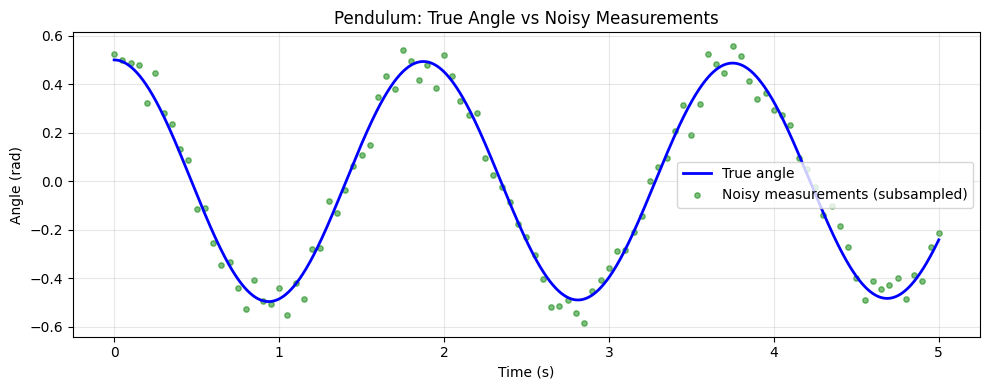

In [7]:
# Visualize true angle vs noisy measurements
true_theta_vals = [s[0, 0] for s in true_states]
meas_theta_vals = [m[0, 0] for m in measurements]

plt.figure(figsize=(10, 4))
plt.plot(times, true_theta_vals, 'b-', linewidth=2, label='True angle')
plt.scatter(times[::25], meas_theta_vals[::25], c='g', s=15, alpha=0.5,
            label='Noisy measurements (subsampled)')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Pendulum: True Angle vs Noisy Measurements')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Pendulum Dynamics Model

The EKF needs to predict how the state evolves over time. For a pendulum, the physics are straightforward:
- The **angle increases** by velocity times the time step
- The **velocity changes** due to gravity pulling the pendulum back and damping slowing it down

The continuous dynamics are:

$$\dot{\theta} = \omega$$
$$\dot{\omega} = -\frac{g}{L}\sin(\theta) - b\omega$$

We discretize with Euler integration to get our state transition function $\mathbf{f}(\mathbf{x}, \Delta t)$:

$$\theta_{k+1} = \theta_k + \Delta t \cdot \omega_k$$
$$\omega_{k+1} = \omega_k + \Delta t \cdot \left(-\frac{g}{L}\sin(\theta_k) - b\omega_k\right)$$

The **Jacobian** $\mathbf{F}$ tells the EKF how sensitive the prediction is to the current state:

$$\mathbf{F} = \frac{\partial \mathbf{f}}{\partial \mathbf{x}} = \begin{bmatrix} 1 & \Delta t \\ -\frac{g}{L}\cos(\theta)\Delta t & 1 - b\Delta t \end{bmatrix}$$

In [8]:
# Physical parameters (must match pendulum.xml)
g = 9.81   # gravity (m/s^2)
L = 1.0    # pendulum length (m)
b = 0.1    # damping coefficient (matches <joint damping="0.1"/>)

def pendulum_f(x, dt):
    """
    State transition function: x_{k+1} = f(x_k, dt)
    
    x: (2,1) state vector [theta, omega]^T
    dt: time step (seconds)
    Returns: (2,1) predicted state
    """
    theta = x[0, 0]  # angle
    omega = x[1, 0]  # angular velocity
    
    # Euler integration of continuous dynamics
    theta_new = theta + dt * omega
    omega_new = omega + dt * (-(g / L) * np.sin(theta) - b * omega)
    
    return np.array([[theta_new], [omega_new]])  # (2,1)


def pendulum_F(x, dt):
    """
    Jacobian of f with respect to x: F = df/dx
    
    x: (2,1) state vector [theta, omega]^T
    dt: time step (seconds)
    Returns: (2,2) Jacobian matrix
    """
    theta = x[0, 0]
    
    # F[i,j] = d(f_i) / d(x_j)
    F = np.array([
        [1.0,                           dt],             # d(theta_new)/d(theta, omega)
        [-dt * (g / L) * np.cos(theta), 1.0 - dt * b]   # d(omega_new)/d(theta, omega)
    ])
    return F  # (2,2)


# Quick sanity check
x_test = np.array([[0.5], [0.0]])  # theta=0.5 rad, omega=0
x_next = pendulum_f(x_test, dt)
F_test = pendulum_F(x_test, dt)
print(f"Test state: {x_test.T}")
print(f"Predicted next state: {x_next.T}")
print(f"Jacobian:\n{F_test}")

Test state: [[0.5 0. ]]
Predicted next state: [[ 0.5        -0.00940633]]
Jacobian:
[[ 1.          0.002     ]
 [-0.01721817  0.9998    ]]


## Section 6: Jacobian Verification

Jacobians are easy to get wrong -- a sign error or missing term will silently corrupt your filter. **Always verify your analytical Jacobian against numerical finite differences.**

The idea is simple: perturb each state variable by a tiny amount, see how the output changes, and compare that numerical derivative to your analytical formula. If they match (within floating-point tolerance), your Jacobian is correct.

In [9]:
def verify_jacobian(f, F, x, dt, eps=1e-7):
    """
    Verify analytical Jacobian F against finite differences.
    
    f: state transition function f(x, dt) -> (n,1)
    F: Jacobian function F(x, dt) -> (n,n)
    x: (n,1) test state
    dt: time step
    Returns: max absolute error between analytical and numerical Jacobians
    """
    n = x.shape[0]
    
    # Compute analytical Jacobian
    F_analytical = F(x, dt)
    
    # Compute numerical Jacobian using scipy approx_fprime
    # approx_fprime expects a 1D input, so we flatten/reshape
    x_flat = x.flatten()
    F_numerical = np.zeros((n, n))
    
    for i in range(n):  # For each output dimension
        def f_i(x_flat_in, idx=i):
            """Return the idx-th component of f as a scalar."""
            x_col = x_flat_in.reshape(-1, 1)
            return f(x_col, dt)[idx, 0]
        
        F_numerical[i, :] = approx_fprime(x_flat, f_i, eps)
    
    # Compute error
    error = np.max(np.abs(F_analytical - F_numerical))
    return error, F_analytical, F_numerical


# Test at multiple states
test_states = [
    ("theta=0 (equilibrium)",       np.array([[0.0],     [0.0]])),
    ("theta=pi/4 (45 degrees)",     np.array([[np.pi/4], [0.5]])),
    ("theta=pi/2 (90 degrees)",     np.array([[np.pi/2], [-1.0]])),
    ("theta=pi (inverted)",         np.array([[np.pi],   [0.0]])),
]

print("Jacobian Verification")
print("=" * 70)
all_passed = True
for name, x_test in test_states:
    error, F_a, F_n = verify_jacobian(pendulum_f, pendulum_F, x_test, dt)
    status = "PASS" if error < 1e-5 else "FAIL"
    if error >= 1e-5:
        all_passed = False
    print(f"\n{name}:")
    print(f"  Analytical:  {F_a[0]}")
    print(f"               {F_a[1]}")
    print(f"  Numerical:   {F_n[0]}")
    print(f"               {F_n[1]}")
    print(f"  Max error: {error:.2e} [{status}]")

print("\n" + "=" * 70)
assert all_passed, "Jacobian verification FAILED at one or more test points!"
print("All Jacobian tests PASSED (error < 1e-5)")

Jacobian Verification

theta=0 (equilibrium):
  Analytical:  [1.    0.002]
               [-0.01962  0.9998 ]
  Numerical:   [1.    0.002]
               [-0.01962  0.9998 ]
  Max error: 3.47e-17 [PASS]

theta=pi/4 (45 degrees):
  Analytical:  [1.    0.002]
               [-0.01387344  0.9998    ]
  Numerical:   [1.    0.002]
               [-0.01387343  0.9998    ]
  Max error: 9.71e-10 [PASS]

theta=pi/2 (90 degrees):
  Analytical:  [1.    0.002]
               [-1.20137851e-18  9.99800000e-01]
  Numerical:   [1.    0.002]
               [0.     0.9998]
  Max error: 1.13e-09 [PASS]

theta=pi (inverted):
  Analytical:  [1.    0.002]
               [0.01962 0.9998 ]
  Numerical:   [1.    0.002]
               [0.01962 0.9998 ]
  Max error: 1.65e-10 [PASS]

All Jacobian tests PASSED (error < 1e-5)


## Section 7: Measurement Model Functions

The measurement model describes what we observe. We only measure the angle (theta), not the velocity. So our measurement function simply extracts the first element of the state.

The key insight: even though we only measure position, the EKF will **estimate velocity too** by using the dynamics model. When the angle changes between timesteps, the filter infers that there must be velocity causing that change.

In [10]:
def measurement_h(x):
    """
    Measurement function: z = h(x)
    We observe only theta (angle), not omega (velocity).
    
    x: (2,1) state vector [theta, omega]^T
    Returns: (1,1) measurement vector [theta]
    """
    return np.array([[x[0, 0]]])  # (1,1)


def measurement_H(x):
    """
    Jacobian of h with respect to x: H = dh/dx
    Since h extracts theta: H = [1, 0]
    
    x: (2,1) state vector (unused, but kept for API consistency)
    Returns: (1,2) Jacobian matrix
    """
    return np.array([[1.0, 0.0]])  # (1,2)


# Quick verification
x_test = np.array([[0.5], [1.0]])
print(f"State: {x_test.T}")
print(f"h(x) = {measurement_h(x_test).T} (observes theta only)")
print(f"H(x) = {measurement_H(x_test)} (linear measurement model)")

State: [[0.5 1. ]]
h(x) = [[0.5]] (observes theta only)
H(x) = [[1. 0.]] (linear measurement model)


## Section 8: EKF Implementation

The EKF has two steps that repeat at every timestep:

1. **Predict**: Use the dynamics model to forecast the next state and grow the uncertainty
2. **Update**: When a measurement arrives, correct the prediction and shrink the uncertainty

Think of it like navigation: you predict where you will be based on your speed and direction (predict), then check your GPS and adjust (update). If your GPS is noisy, you trust your prediction more. If your model is poor, you trust the GPS more. The Kalman gain automatically balances these two sources of information.

In [12]:
def ekf_predict(x, P, f, F, Q, dt):
    """
    EKF Prediction Step: propagate state and covariance forward in time.
    
    x: (n,1) state estimate
    P: (n,n) state covariance (our uncertainty)
    f: state transition function f(x, dt) -> (n,1)
    F: Jacobian function F(x, dt) -> (n,n)
    Q: (n,n) process noise covariance (how much we distrust the model)
    dt: time step
    
    Returns: (x_pred, P_pred)
    """
    # Predict the next state using the nonlinear dynamics
    x_pred = f(x, dt)                     # (n,1) predicted state
    
    # Linearize dynamics at current state
    F_k = F(x, dt)                         # (n,n) Jacobian
    
    # Propagate covariance: uncertainty grows through dynamics + process noise
    P_pred = F_k @ P @ F_k.T + Q           # (n,n) predicted covariance
    
    return x_pred, P_pred


def ekf_update(x, P, z, h, H, R):
    """
    EKF Update Step: correct prediction with a measurement.
    
    x: (n,1) predicted state
    P: (n,n) predicted covariance
    z: (m,1) measurement
    h: measurement function h(x) -> (m,1)
    H: Jacobian function H(x) -> (m,n)
    R: (m,m) measurement noise covariance (how much we distrust the sensor)
    
    Returns: (x_upd, P_upd)
    """
    # Linearize measurement model at predicted state
    H_k = H(x)                             # (m,n) measurement Jacobian
    
    # Innovation: difference between actual measurement and predicted measurement
    y = z - h(x)                           # (m,1) innovation ("surprise")
    
    # Innovation covariance: how uncertain is our predicted measurement?
    S = H_k @ P @ H_k.T + R                # (m,m)
    
    # Kalman gain: how much to trust measurement vs prediction
    # Large K -> trust measurement more; Small K -> trust prediction more
    K = P @ H_k.T @ np.linalg.inv(S)       # (n,m)
    
    # Correct state estimate with weighted innovation
    x_upd = x + K @ y                      # (n,1)
    
    # Update covariance using Joseph form for numerical stability
    # (Standard form P = (I-KH)P can lose positive-definiteness)
    I_KH = np.eye(x.shape[0]) - K @ H_k    # (n,n)
    P_upd = I_KH @ P @ I_KH.T + K @ R @ K.T  # (n,n) Joseph form
    
    return x_upd, P_upd


print("EKF functions defined: ekf_predict, ekf_update")
print("  - ekf_predict: propagates state and uncertainty forward")
print("  - ekf_update: corrects prediction with measurement")
print("  - Uses Joseph form for numerically stable covariance update")

EKF functions defined: ekf_predict, ekf_update
  - ekf_predict: propagates state and uncertainty forward
  - ekf_update: corrects prediction with measurement
  - Uses Joseph form for numerically stable covariance update


## Section 9: Running the EKF

Now we have all the pieces. Let's run the EKF on our simulated pendulum data:
- Start with an initial guess (zero state, moderate uncertainty)
- At each timestep: predict forward, then update with the noisy measurement
- Collect the estimated states to compare with ground truth

In [13]:
# EKF initialization
x_est = np.array([[0.0], [0.0]])  # Initial guess: zero angle, zero velocity
P_est = np.eye(2) * 0.1           # Initial uncertainty: moderate

# Noise covariance matrices
# Q: process noise -- how much we distrust our dynamics model
# Larger Q = model is less trustworthy, filter relies more on measurements
Q = np.diag([0.01, 0.1])          # (2,2) process noise [position, velocity]

# R: measurement noise -- how much we distrust the sensor
# Should match the actual sensor noise (noise_std^2 = 0.05^2 = 0.0025)
R = np.array([[noise_std**2]])     # (1,1) measurement noise

# Run EKF
estimates = []       # List of (2,1) estimated states
covariances = []     # List of (2,2) covariance matrices

for k in range(len(measurements)):
    # Predict step: use dynamics model to forecast
    x_pred, P_pred = ekf_predict(x_est, P_est, pendulum_f, pendulum_F, Q, dt)
    
    # Update step: correct with noisy measurement
    x_est, P_est = ekf_update(x_pred, P_pred, measurements[k],
                               measurement_h, measurement_H, R)
    
    # Store results
    estimates.append(x_est.copy())      # .copy() to avoid reference issues
    covariances.append(P_est.copy())

print(f"EKF complete: {len(estimates)} timesteps processed")
print(f"Final state estimate: theta={x_est[0,0]:.4f} rad, omega={x_est[1,0]:.4f} rad/s")
print(f"Final uncertainty (1-sigma): theta={np.sqrt(P_est[0,0]):.4f} rad, omega={np.sqrt(P_est[1,1]):.4f} rad/s")

EKF complete: 2501 timesteps processed
Final state estimate: theta=-0.2152 rad, omega=1.3018 rad/s
Final uncertainty (1-sigma): theta=0.0455 rad, omega=3.9227 rad/s


## Section 10: Visualization

Let's see how well the EKF tracked the true pendulum state. We plot:
- **Position (angle)**: true vs estimated vs measurements
- **Velocity**: true vs estimated -- note that we estimated velocity from position-only measurements!

In [14]:
def plot_ekf_results(times, true_states, estimates, measurements=None,
                     covariances=None, title="EKF State Estimation: Pendulum"):
    """
    Plot EKF estimated vs true trajectory.
    
    times: (N,) array of time values
    true_states: list of (2,1) arrays [theta, omega]
    estimates: list of (2,1) arrays [theta_est, omega_est]
    measurements: optional list of (1,1) arrays [theta_measured]
    covariances: optional list of (2,2) arrays for uncertainty bands
    """
    true_theta = [s[0, 0] for s in true_states]
    true_omega = [s[1, 0] for s in true_states]
    est_theta = [s[0, 0] for s in estimates]
    est_omega = [s[1, 0] for s in estimates]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    
    # --- Position subplot ---
    axes[0].plot(times, true_theta, 'b-', linewidth=2, label='True')
    axes[0].plot(times, est_theta, 'r--', linewidth=2, label='EKF Estimate')
    if measurements is not None:
        meas_theta = [m[0, 0] for m in measurements]
        # Subsample measurements for cleaner plot
        step = max(1, len(times) // 200)
        axes[0].scatter(times[::step], meas_theta[::step], c='g', s=10,
                       alpha=0.4, label='Measurements', zorder=1)
    if covariances is not None:
        sigma_theta = [np.sqrt(P[0, 0]) for P in covariances]
        upper = [est_theta[i] + 2*sigma_theta[i] for i in range(len(est_theta))]
        lower = [est_theta[i] - 2*sigma_theta[i] for i in range(len(est_theta))]
        axes[0].fill_between(times, lower, upper, color='red', alpha=0.1, label='2-sigma')
    axes[0].set_ylabel('Angle (rad)')
    axes[0].legend(loc='upper right')
    axes[0].set_title('Position: True vs Estimated')
    axes[0].grid(True, alpha=0.3)
    
    # --- Velocity subplot ---
    axes[1].plot(times, true_omega, 'b-', linewidth=2, label='True')
    axes[1].plot(times, est_omega, 'r--', linewidth=2, label='EKF Estimate')
    if covariances is not None:
        sigma_omega = [np.sqrt(P[1, 1]) for P in covariances]
        upper_v = [est_omega[i] + 2*sigma_omega[i] for i in range(len(est_omega))]
        lower_v = [est_omega[i] - 2*sigma_omega[i] for i in range(len(est_omega))]
        axes[1].fill_between(times, lower_v, upper_v, color='red', alpha=0.1, label='2-sigma')
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_xlabel('Time (s)')
    axes[1].legend(loc='upper right')
    axes[1].set_title('Velocity: True vs Estimated (from position-only measurements!)')
    axes[1].grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

In [15]:
fig = plot_ekf_results(times, true_states, estimates, measurements, covariances)
plt.show()

# Compute tracking error statistics
theta_errors = [abs(estimates[i][0,0] - true_states[i][0,0]) for i in range(len(estimates))]
omega_errors = [abs(estimates[i][1,0] - true_states[i][1,0]) for i in range(len(estimates))]
print(f"\nTracking Error Statistics (after first 0.5s convergence):")
n_skip = int(0.5 / dt)  # Skip initial convergence period
print(f"  Position RMSE: {np.sqrt(np.mean(np.array(theta_errors[n_skip:])**2)):.4f} rad")
print(f"  Velocity RMSE: {np.sqrt(np.mean(np.array(omega_errors[n_skip:])**2)):.4f} rad/s")


Tracking Error Statistics (after first 0.5s convergence):
  Position RMSE: 0.0414 rad
  Velocity RMSE: 0.1760 rad/s


## Section 11: Interactive Q/R Exploration

The two most important tuning knobs in the EKF are the noise covariance matrices:

- **Q (process noise)**: Controls how much you trust the dynamics model
  - Q too low: filter trusts model too much, estimates lag behind reality
  - Q too high: filter treats model as unreliable, estimates become noisy

- **R (measurement noise)**: Controls how much you trust the sensor
  - R too low: filter trusts measurements too much, follows sensor noise
  - R too high: filter ignores measurements, relies only on model prediction

Use the sliders below to see these effects in action. Click **Run Interact** after adjusting the sliders.

In [16]:
def run_ekf_with_params(q_scale, r_scale):
    """
    Run the EKF with scaled Q and R matrices.
    Returns estimated states and covariances.
    """
    Q_scaled = Q * q_scale
    R_scaled = R * r_scale
    
    x_e = np.array([[0.0], [0.0]])
    P_e = np.eye(2) * 0.1
    
    est_list = []
    cov_list = []
    
    for k in range(len(measurements)):
        x_p, P_p = ekf_predict(x_e, P_e, pendulum_f, pendulum_F, Q_scaled, dt)
        x_e, P_e = ekf_update(x_p, P_p, measurements[k],
                               measurement_h, measurement_H, R_scaled)
        est_list.append(x_e.copy())
        cov_list.append(P_e.copy())
    
    return est_list, cov_list


@interact_manual(
    q_scale=FloatLogSlider(value=1.0, base=10, min=-3, max=1, step=0.1,
                           description='Q scale:', readout_format='.3f'),
    r_scale=FloatLogSlider(value=1.0, base=10, min=-3, max=1, step=0.1,
                           description='R scale:', readout_format='.3f')
)
def explore_qr(q_scale, r_scale):
    """Explore the effect of Q and R scaling on EKF performance."""
    est_scaled, cov_scaled = run_ekf_with_params(q_scale, r_scale)
    
    fig = plot_ekf_results(times, true_states, est_scaled, measurements, cov_scaled,
                           title=f"EKF with Q*{q_scale:.3f}, R*{r_scale:.3f}")
    plt.show()
    
    # Compute and display error metrics
    n_skip = int(0.5 / dt)
    theta_err = [abs(est_scaled[i][0,0] - true_states[i][0,0]) for i in range(n_skip, len(est_scaled))]
    omega_err = [abs(est_scaled[i][1,0] - true_states[i][1,0]) for i in range(n_skip, len(est_scaled))]
    print(f"Position RMSE: {np.sqrt(np.mean(np.array(theta_err)**2)):.4f} rad")
    print(f"Velocity RMSE: {np.sqrt(np.mean(np.array(omega_err)**2)):.4f} rad/s")
    print()
    print("Tuning guide:")
    print("  Q too low  -> estimates lag behind (filter trusts model too much)")
    print("  Q too high -> estimates are noisy (filter distrusts model)")
    print("  R too low  -> follows measurement noise (filter trusts sensor too much)")
    print("  R too high -> ignores measurements (filter trusts only model)")

interactive(children=(FloatLogSlider(value=1.0, description='Q scale:', max=1.0, min=-3.0, readout_format='.3f…

## Section 12: Key Takeaways

### What We Built
We implemented a complete Extended Kalman Filter from scratch and used it to estimate the state of a pendulum simulated in MuJoCo.

### Key Insights

1. **Velocity from position**: The EKF estimated angular velocity even though we only measured angle. This works because the dynamics model encodes the relationship between position and velocity -- if the angle is changing, there must be velocity.

2. **Predict-Update cycle**: Each timestep has two phases: predict (use the model to forecast) and update (correct with measurement). The Kalman gain automatically balances trust between model and sensor.

3. **Jacobian correctness matters**: We verified our Jacobians against finite differences. A wrong Jacobian will cause the filter to diverge -- this is the most common EKF implementation bug.

4. **Q and R tuning**: Process noise Q and measurement noise R control the filter's behavior. Understanding their effect is crucial for real-world deployment.

5. **Joseph form**: We used the Joseph form for covariance updates instead of the simpler `P = (I-KH)P` to maintain numerical stability.

### When Does the EKF Work Well?
- System dynamics are **mildly nonlinear** (linearization is a good approximation)
- Noise is approximately **Gaussian**
- The dynamics model is **reasonably accurate**

### When Does the EKF Struggle?
- **Highly nonlinear** systems (large angle pendulum near the top)
- **Non-Gaussian** noise (outliers, sensor dropouts)
- **Poor model** (missing physics, wrong parameters)

### Next Steps
In the next notebook, we will tackle a more complex system: the **cart-pole**. This introduces:
- Higher-dimensional state space (4 states instead of 2)
- Partial observability (some states harder to observe)
- More interesting dynamics for the EKF to track